# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Nabiel Muaafii Rahman
- **Email:** mc001d5y0851@student.devacademy.id
- **ID Dicoding:** MC001D5Y0851

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import AdamW, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Preparation

### Data Loading

In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors


In [ ]:
!unzip intel-image-classification.zip -d "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7506.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7537.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7539.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7551.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7560.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7565.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7578.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7581.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7586.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR

In [ ]:
# Direktori awal untuk train dan test
train_dir = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train"
test_dir = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_test/seg_test"

# Direktori baru untuk dataset gabungan
combined_dir = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset"

In [ ]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [ ]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

### Data Preprocessing

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
dict_image = {}

# Tentukan path sumber train
path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    dict_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(dict_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(dict_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

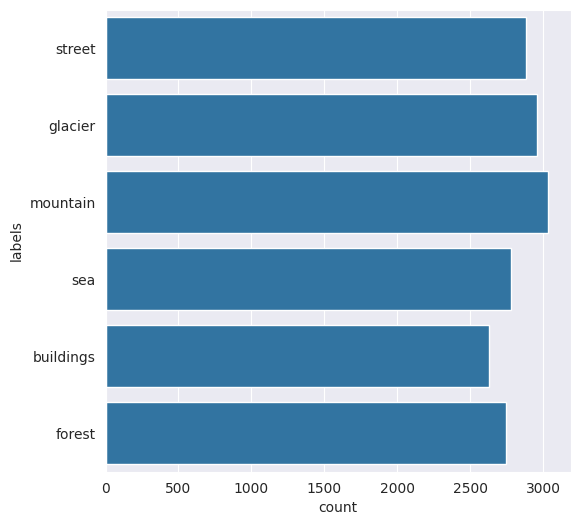

In [9]:
# Definisikan path sumber
data_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(data_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [10]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= '/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
buildings,2628
forest,2745
glacier,2957
mountain,3037
sea,2784
street,2883


#### Split Dataset

In [11]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [12]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [13]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/"


set    labels   
test   buildings     524
       forest        567
       glacier       569
       mountain      625
       sea           544
       street        578
train  buildings    2104
       forest       2178
       glacier      2388
       mountain     2412
       sea          2240
       street       2305
dtype: int64 


                                                    path    labels    set
11159  /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...    street  train
8415   /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...  mountain  train
15827  /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...    street   test
98     /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...   glacier  train
6556   /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...       sea  train


In [ ]:
# Iterate through the dataframe and copy images to train/test directories
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    # If the file path is invalid, it's possible the 'image' column contains the file name
    # and not the full path. In such case, construct the path using datasource_path, labels, and the file name
    if not os.path.exists(file_path):
        file_path = os.path.join(datasource_path, row['labels'], row['file_name']) # Use 'file_name' instead of 'image'

    # Check if the file exists before proceeding
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        continue  # Skip to the next iteration

    # Buat direktori tujuan folder
    os.makedirs(os.path.join(dataset_path, row['set'], row['labels']), exist_ok=True)

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Salin file dari sumber ke tujuan
    if not os.path.exists(file_dest):
        shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

KeyboardInterrupt: 

In [14]:
# Definisikan direktori training dan test
TRAIN_DIR = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/train"
TEST_DIR = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/test"

train_buildings = os.path.join(TRAIN_DIR + '/buildings')
train_forest = os.path.join(TRAIN_DIR + '/forest')
test_buildings = os.path.join(TEST_DIR + '/buildings')
test_forest = os.path.join(TEST_DIR + '/forest')
train_glacier = os.path.join(TRAIN_DIR + '/glacier')
test_glacier = os.path.join(TEST_DIR + '/glacier')
train_mountain = os.path.join(TRAIN_DIR + '/mountain')
test_mountain = os.path.join(TEST_DIR + '/mountain')
train_sea = os.path.join(TRAIN_DIR + '/sea')
test_sea = os.path.join(TEST_DIR + '/sea')
train_street = os.path.join(TRAIN_DIR + '/street')
test_street = os.path.join(TEST_DIR + '/street')

print("Total number of buildings images in training set: ",len(os.listdir(train_buildings)))
print("Total number of forest images in training set: ",len(os.listdir(train_forest)))
print("Total number of glacier images in training set: ",len(os.listdir(train_glacier)))
print("Total number of mountain images in training set: ",len(os.listdir(train_mountain)))
print("Total number of sea images in training set: ",len(os.listdir(train_sea)))
print("Total number of street images in training set: ",len(os.listdir(train_street)))
print("Total number of buildings images in test set: ",len(os.listdir(test_buildings)))
print("Total number of forest images in test set: ",len(os.listdir(test_forest)))
print("Total number of glacier images in test set: ",len(os.listdir(test_glacier)))
print("Total number of mountain images in test set: ",len(os.listdir(test_mountain)))
print("Total number of sea images in test set: ",len(os.listdir(test_sea)))
print("Total number of street images in test set: ",len(os.listdir(test_street)))

Total number of buildings images in training set:  2104
Total number of forest images in training set:  2177
Total number of glacier images in training set:  2388
Total number of mountain images in training set:  2411
Total number of sea images in training set:  2240
Total number of street images in training set:  2303
Total number of buildings images in test set:  524
Total number of forest images in test set:  567
Total number of glacier images in test set:  569
Total number of mountain images in test set:  625
Total number of sea images in test set:  544
Total number of street images in test set:  578


In [15]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='categorical',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='categorical',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 10901 images belonging to 6 classes.
Found 2722 images belonging to 6 classes.
Found 3407 images belonging to 6 classes.


In [16]:
import os
from PIL import Image

def remove_corrupted_images(directory):
    removed = 0
    for root, _, files in os.walk(directory):
        for filename in files:
            file_path = os.path.join(root, filename)
            try:
                img = Image.open(file_path)
                img.verify()  # akan error jika file rusak
            except Exception as e:
                print(f"❌ Removed corrupted: {file_path} ({e})")
                os.remove(file_path)
                removed += 1
    print(f"\n✅ Total corrupted images removed: {removed}")

# Ganti ini dengan folder train dan test kamu
remove_corrupted_images(TRAIN_DIR)
remove_corrupted_images(TEST_DIR)


✅ Total corrupted images removed: 0

✅ Total corrupted images removed: 0


## Modelling

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
# Bersihkan session
tf.keras.backend.clear_session()
model_1 = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,1), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4 - tambahan
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(6, activation='softmax')
])
# Compile
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             

 Total params: 1,276,518 (4.87 MB)

 Trainable params: 1,273,830 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [18]:
# Training
history = model_1.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.4496 - loss: 1.7226
Epoch 1: val_loss improved from inf to 2.96066, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 96s 214ms/step - accuracy: 0.4498 - loss: 1.7217 - val_accuracy: 0.1793 - val_loss: 2.9607 - learning_rate: 1.0000e-04
Epoch 2/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.6627 - loss: 1.0594
Epoch 2: val_loss improved from 2.96066 to 1.21964, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - accuracy: 0.6627 - loss: 1.0593 - val_accuracy: 0.5944 - val_loss: 1.2196 - learning_rate: 1.0000e-04
Epoch 3/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7148 - loss: 0.9235
Epoch 3: val_loss improved from 1.21964 to 0.76544, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 47s 138ms/step - accuracy: 0.7148 - loss: 0.9235 - val_accuracy: 0.7652 - val_loss: 0.7654 - learning_rate: 1.0000e-04
Epoch 4/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7414 - loss: 0.8417
Epoch 4: val_loss did not improve from 0.76544
341/341 ━━━━━━━━━━━━━━━━━━━━ 49s 143ms/step - accuracy: 0.7414 - loss: 0.8416 - val_accuracy: 0.7597 - val_loss: 0.8078 - learning_rate: 1.0000e-04
Epoch 5/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7667 - loss: 0.7706
Epoch 5: val_loss improved from 0.76544 to 0.69160, saving model to best_model.h5


...

341/341 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.7991 - loss: 0.6847 - val_accuracy: 0.8189 - val_loss: 0.6154 - learning_rate: 1.0000e-04
Epoch 8/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8098 - loss: 0.6489
Epoch 8: val_loss did not improve from 0.61535
341/341 ━━━━━━━━━━━━━━━━━━━━ 47s 136ms/step - accuracy: 0.8098 - loss: 0.6489 - val_accuracy: 0.7542 - val_loss: 0.8447 - learning_rate: 1.0000e-04
Epoch 9/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8240 - loss: 0.6116
Epoch 9: val_loss improved from 0.61535 to 0.56900, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 47s 138ms/step - accuracy: 0.8240 - loss: 0.6117 - val_accuracy: 0.8332 - val_loss: 0.5690 - learning_rate: 1.0000e-04
Epoch 10/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8413 - loss: 0.5826
Epoch 10: val_loss did not improve from 0.56900
341/341 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.8413 - loss: 0.5826 - val_accuracy: 0.8112 - val_loss: 0.6718 - learning_rate: 1.0000e-04
Epoch 11/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8454 - loss: 0.5592
Epoch 11: val_loss improved from 0.56900 to 0.53587, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - accuracy: 0.8454 - loss: 0.5592 - val_accuracy: 0.8523 - val_loss: 0.5359 - learning_rate: 1.0000e-04
Epoch 12/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8528 - loss: 0.5285
Epoch 12: val_loss did not improve from 0.53587
341/341 ━━━━━━━━━━━━━━━━━━━━ 49s 143ms/step - accuracy: 0.8528 - loss: 0.5285 - val_accuracy: 0.8108 - val_loss: 0.6432 - learning_rate: 1.0000e-04
Epoch 13/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8611 - loss: 0.5032
Epoch 13: val_loss did not improve from 0.53587
341/341 ━━━━━━━━━━━━━━━━━━━━ 49s 145ms/step - accuracy: 0.8612 - loss: 0.5032 - val_accuracy: 0.8288 - val_loss: 0.6099 - learning_rate: 1.0000e-04
Epoch 14/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8754 - loss: 0.4683
Epoch 14: val_loss did not improve from 0.53587

Epoch 14: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 141ms/step - accuracy: 0.8754 -

341/341 ━━━━━━━━━━━━━━━━━━━━ 49s 144ms/step - accuracy: 0.8989 - loss: 0.4042 - val_accuracy: 0.8597 - val_loss: 0.5273 - learning_rate: 5.0000e-05
Epoch 16/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9147 - loss: 0.3578
Epoch 16: val_loss did not improve from 0.52732
341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 142ms/step - accuracy: 0.9147 - loss: 0.3578 - val_accuracy: 0.8560 - val_loss: 0.5493 - learning_rate: 5.0000e-05
Epoch 17/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9314 - loss: 0.3163
Epoch 17: val_loss did not improve from 0.52732
341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - accuracy: 0.9314 - loss: 0.3163 - val_accuracy: 0.8604 - val_loss: 0.5501 - learning_rate: 5.0000e-05
Epoch 18/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9367 - loss: 0.3121
Epoch 18: val_loss did not improve from 0.52732

Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
341/341 ━━━━━━━━━━━━━━━━━━━━ 49s 143ms/step - accuracy: 0.9367 -

341/341 ━━━━━━━━━━━━━━━━━━━━ 46s 136ms/step - accuracy: 0.9565 - loss: 0.2526 - val_accuracy: 0.8777 - val_loss: 0.5060 - learning_rate: 2.5000e-05
Epoch 20/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9685 - loss: 0.2257
Epoch 20: val_loss did not improve from 0.50601
341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 141ms/step - accuracy: 0.9685 - loss: 0.2257 - val_accuracy: 0.8740 - val_loss: 0.5092 - learning_rate: 2.5000e-05
Epoch 21/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9748 - loss: 0.2128
Epoch 21: val_loss did not improve from 0.50601
341/341 ━━━━━━━━━━━━━━━━━━━━ 47s 136ms/step - accuracy: 0.9748 - loss: 0.2128 - val_accuracy: 0.8582 - val_loss: 0.5557 - learning_rate: 2.5000e-05
Epoch 22/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9785 - loss: 0.2002
Epoch 22: val_loss did not improve from 0.50601

Epoch 22: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
341/341 ━━━━━━━━━━━━━━━━━━━━ 49s 144ms/step - accuracy: 0.9785 -

## Evaluasi dan Visualisasi

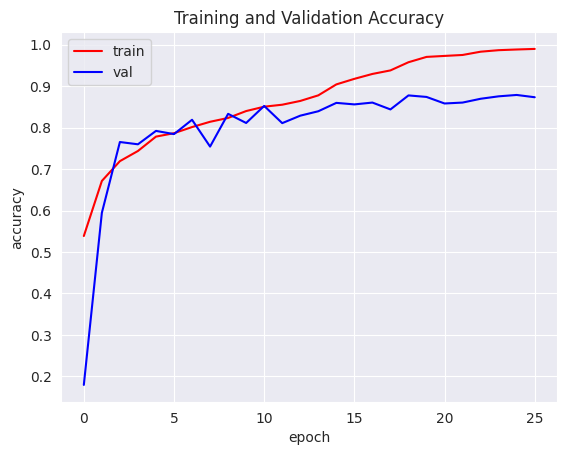

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()



              precision    recall  f1-score   support

   buildings     0.8719    0.8836    0.8777       524
      forest     0.9701    0.9718    0.9709       567
     glacier     0.7956    0.8348    0.8148       569
    mountain     0.8286    0.8432    0.8358       625
         sea     0.9195    0.8401    0.8780       544
      street     0.8945    0.8945    0.8945       578

    accuracy                         0.8776      3407
   macro avg     0.8800    0.8780    0.8786      3407
weighted avg     0.8790    0.8776    0.8779      3407



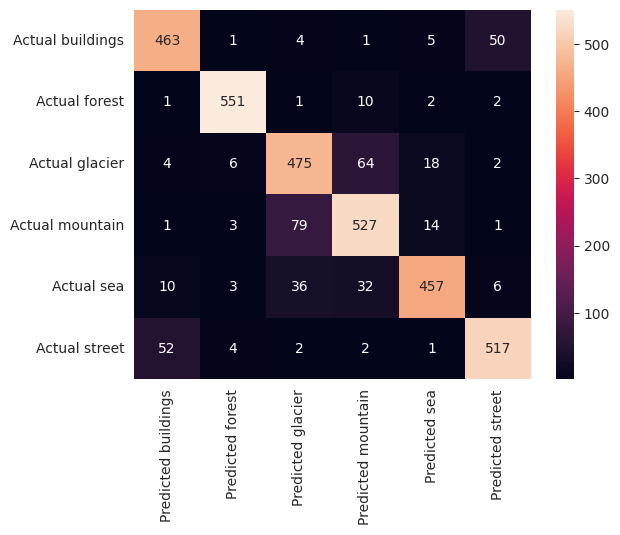

In [20]:
# Reset generator
test_generator.reset()

# Prediksi
preds_1 = model_1.predict(test_generator, verbose=0)
preds_1 = preds_1.copy()
preds_1 = np.argmax(preds_1, axis=1)  # karena output sekarang multi-class (6 kelas)

# Daftar nama kelas (urutannya harus sesuai label encoding di generator)
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Confusion Matrix
cm = pd.DataFrame(
    data=confusion_matrix(test_generator.classes, preds_1),
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names]
)
sns.heatmap(cm, annot=True, fmt="d")

# Classification Report
print("\n")
print(classification_report(
    y_true=test_generator.classes,
    y_pred=preds_1,
    target_names=class_names,
    digits=4
))

In [21]:
# Assuming 'history' is the training history object from model.fit
# and 'test_generator' and 'class_names' are defined as in the original code.

# Evaluate the model
_, accuracy = model_1.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


3407/3407 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8899 - loss: 0.4919
Test Accuracy: 87.76%


## Konversi Model

In [22]:
model_1.export('/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/model')

Saved artifact at '/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137035839403408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839404560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839702224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839702608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839403216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839701840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839405520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839703184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137035839702800: TensorSpec(shape=(), dtype=tf.re

In [23]:
source_folder = "/content/best_model.h5"  # Replace with the actual source folder path
destination_folder = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR"  # Replace with the desired destination

# Move the folder
shutil.move(source_folder, destination_folder)


'/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/best_model.h5'

In [24]:
# Install tensorflowjs
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [25]:
os.mkdir("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tfjs_model")

In [26]:
import tensorflowjs as tfjs
from tensorflow import keras

# Load model
model = keras.models.load_model("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/best_model.h5")

# Convert to TFJS format
tfjs.converters.save_keras_model(
    model,
    "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tfjs_model"
)

failed to lookup keras version from the file,
    this is likely a weight only file


In [27]:
os.mkdir("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/saved_model")

In [28]:
tf.saved_model.save(model_1, '/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/saved_model')

In [29]:
os.mkdir("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tflite")

In [30]:
# Convert SavedModel menjadi vegs.tflite
converter = tf.lite.TFLiteConverter.from_saved_model("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/saved_model")
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tflite/place.tflite')
tflite_model_file.write_bytes(tflite_model)

42212

In [31]:
!pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.6.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.6
ale-py==0.11.0
altair==5.5.0
annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.2
arviz==0.21.0
astropy==7.0.1
astropy-iers-data==0.2025.4.28.0.37.27
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.1.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blosc2==3.3.1
bokeh==3.7.2
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.2
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.4.26
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.89
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.21.0
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
commun

## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: buildings


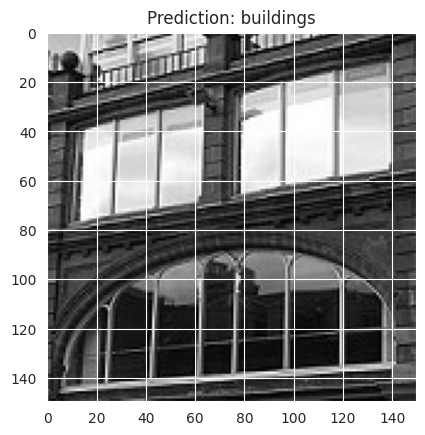

In [32]:
# Load the trained model
model = keras.models.load_model("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/best_model.h5")

# Define the path to your validation image
image_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/test/buildings/10126.jpg" # Example path, replace with your image

# Preprocess the image
img = Image.open(image_path).convert("L")
img = img.resize((150, 150))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
img_array = np.expand_dims(img_array, axis=-1)

# Perform inference
predictions = model.predict(img_array)

# Get the predicted class
predicted_class = np.argmax(predictions[0])

# Get class labels from the generator (assuming you have it defined)
class_labels = list(train_generator.class_indices.keys())

# Print the prediction
print(f"Predicted class: {class_labels[predicted_class]}")

# Display the image
plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {class_labels[predicted_class]}")
plt.show()
